<a href="https://colab.research.google.com/github/dikshi-shah/Automated-Retinopathy-Detection/blob/main/Retinopathy_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
import os
import zipfile

dir1 = '/content/drive/MyDrive/Retina images.zip'
extract_dir = '/content/dataset'

with zipfile.ZipFile(dir1, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

dir1 = os.path.join(extract_dir, 'dataset')

detection = [class_name for class_name in os.listdir(dir1) if os.path.isdir(os.path.join(dir1, class_name)) and class_name != 'iris_Image_Dataset']


print(detection)

['normal', 'cataract', 'diabetic_retinopathy', 'glaucoma']


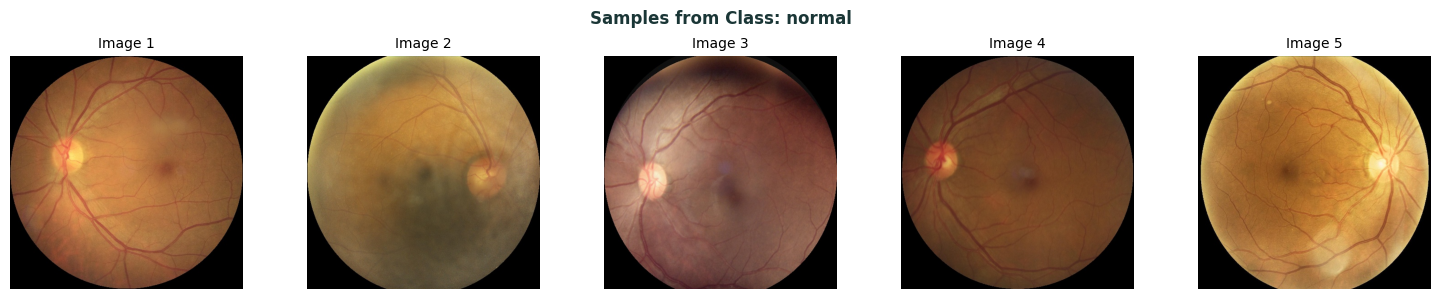

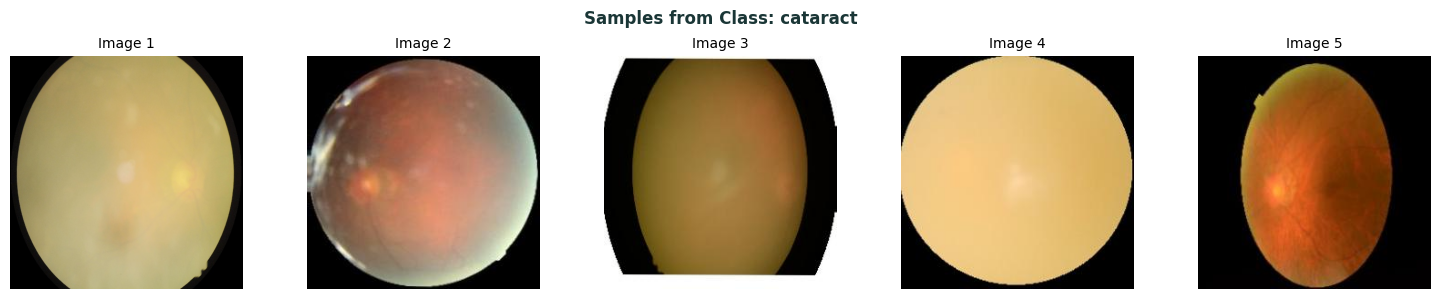

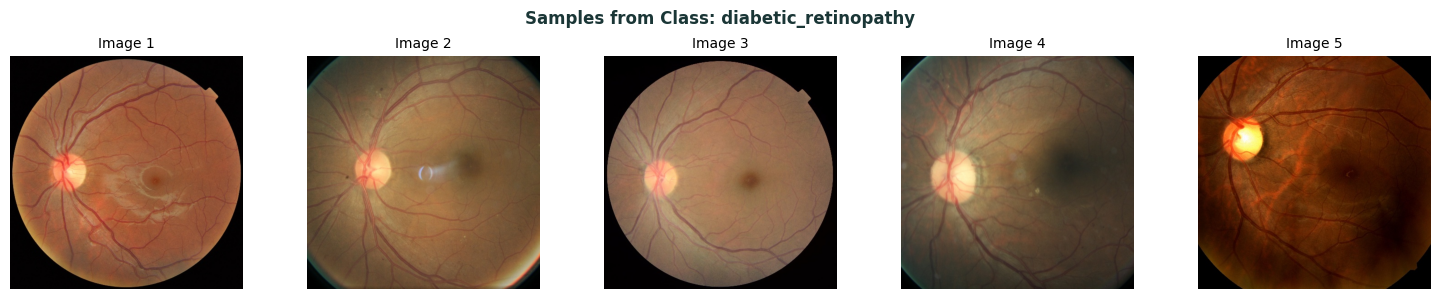

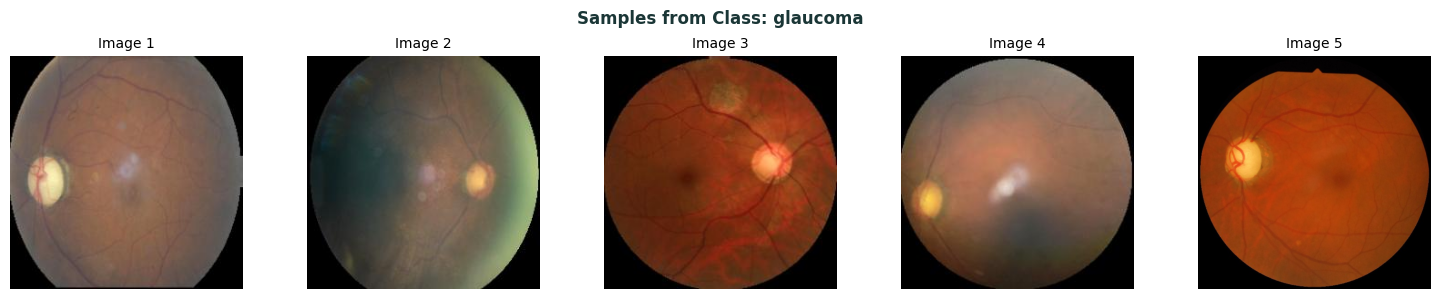

In [ ]:
import random
for class_name in detection:
    class_path = os.path.join(dir1, class_name)
    images = os.listdir(class_path)
    random_images = random.choices(images, k=5)

    fig, ax = plt.subplots(1, 5, figsize=(15, 3))
    plt.suptitle(f'Samples from Class: {class_name}', fontsize=12, fontweight='bold', color='#1A3636')

    for i in range(5):
        img_path = os.path.join(class_path, random_images[i])
        img = tf.keras.utils.load_img(img_path)
        ax[i].imshow(img)
        ax[i].axis('off')

        ax[i].set_title(f'Image {i + 1}', fontsize=10)

    plt.tight_layout()
    plt.show()

In [ ]:
data = []
for class_name in detection:
    class_path = os.path.join(dir1, class_name)
    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)
        data.append({'path': image_path, 'label': class_name})

df = pd.DataFrame(data)
display(df.head())

,path,label
0,/content/dataset/dataset/normal/2603_right.jpg,normal
1,/content/dataset/dataset/normal/2695_left.jpg,normal
2,/content/dataset/dataset/normal/2443_right.jpg,normal
3,/content/dataset/dataset/normal/3241_left.jpg,normal
4,/content/dataset/dataset/normal/3176_right.jpg,normal


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("Shape of training set:", train_df.shape)
print("Shape of validation set:", val_df.shape)
print("Shape of test set:", test_df.shape)

Shape of training set: (2951, 2)
Shape of validation set: (633, 2)
Shape of test set: (633, 2)


In [ ]:
import numpy as np

# The 'img' variable from previous cells is a PIL Image object.
# To get its pixel values and apply .min()/.max(), it needs to be converted to a NumPy array.
img_array = np.array(img)

print(f"Minimum pixel value: {img_array.min()}")
print(f"Maximum pixel value: {img_array.max()}")

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=dir1,
    x_col='path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=dir1,
    x_col='path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=dir1,
    x_col='path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2951 validated image filenames belonging to 4 classes.
Found 633 validated image filenames belonging to 4 classes.
Found 633 validated image filenames belonging to 4 classes.


In [ ]:
tf.random.set_seed(42)

model_1 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, 2,activation = 'relu'),
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Conv2D(81, 2),
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Conv2D(100, 2,activation = 'relu'),
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Conv2D(121,2),
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Conv2D(124, 2,activation = 'relu'),
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(4, activation="softmax")
])

model_1.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

history_1 = model_1.fit(train_generator,
                        epochs=10,
                        validation_data = val_generator
                       )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 388ms/step - accuracy: 0.3427 - loss: 1.3291 - val_accuracy: 0.5308 - val_loss: 1.1325
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 330ms/step - accuracy: 0.5347 - loss: 1.0654 - val_accuracy: 0.5861 - val_loss: 1.0096
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 335ms/step - accuracy: 0.5876 - loss: 0.9842 - val_accuracy: 0.6635 - val_loss: 0.8444
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 336ms/step - accuracy: 0.6225 - loss: 0.8944 - val_accuracy: 0.6872 - val_loss: 0.7770
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 331ms/step - accuracy: 0.6405 - loss: 0.8724 - val_accuracy: 0.7014 - val_loss: 0.7433
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 331ms/step - accuracy: 0.6789 - loss: 0.8012 - val_accuracy: 0.6556 - val_loss: 0.8448
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 334ms/step - accuracy: 0.6810 - loss: 0.7812 - val_accuracy: 0.7251 - val_loss: 0.7183
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 331ms/step - accuracy: 0.7280 - loss: 0.7038 - val_accu